# 01 Power Curve Fitting

This notebook explains how SCADA-style turbine data is cleaned, preprocessed, binned, and converted into an empirical power curve. The sample data is synthetic and public-safe.

## Data Description

The sample SCADA table contains `timestamp`, `turbine_id`, `wind_speed`, `power_kw`, and `status`. In the private project these fields came from turbine-level 15-minute reports; here they are synthetic examples with the same schema.

In [ ]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wind_power_baselines.preprocessing import clean_scada
from wind_power_baselines.power_curve import build_power_curve
scada = pd.read_csv(PROJECT_ROOT / 'data_sample' / 'sample_turbine_scada.csv')
scada.head()

## Cleaning And Preprocessing

The cleaning step parses timestamps, keeps normal operating rows, removes impossible wind speeds and negative power values, deduplicates turbine timestamps, and adds month/season labels. This prevents outage and sensor artifacts from distorting the curve.

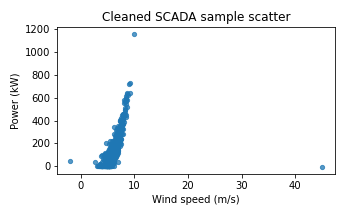

In [1]:
cleaned = clean_scada(scada)
print({'raw_rows': len(scada), 'cleaned_rows': len(cleaned)})
cleaned.head()

## Power Curve Construction

The curve uses wind-speed bins and median power. Median binning is preferred over direct scatter fitting because real turbine data often contains curtailment, downtime, and outliers.

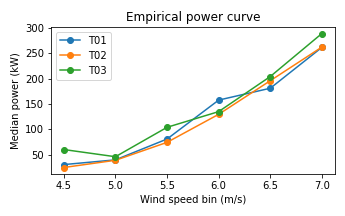

In [1]:
curve = build_power_curve(cleaned, bin_width=0.5, min_samples=2)
curve.to_csv(PROJECT_ROOT / 'data_sample' / 'sample_power_curve.csv', index=False)
curve.head()

## Result

The output table `data_sample/sample_power_curve.csv` is the bridge into the point-forecast notebook: forecast wind speed is mapped to power through these empirical bins.